In [3]:
library(ggplot2)
library(foreach)

library(Matrix)

library(foreach)
library(doMC)
library(cowplot)
library(geometry)
library(cmaes)
library(orthopolynom)
library(DiceDesign)
library(randtoolbox)
library(DiceKriging)
library(viridis)

In [4]:
options(repr.plot.width = 14, repr.plot.height = 8) # size of plots

save_path = "first_scenario_earth/"
save_data = TRUE
n_batch = 5
registerDoMC(cores = n_batch)

optim = TRUE # if optimization of hyperparameters

In [5]:
source("../utils_matrix_triangu.R") 
source("utils_triangu.R")
source("../utils_plot.R")
source("../utils_splines.R")
source("../utils_harmonics.R")

### Load data

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.”


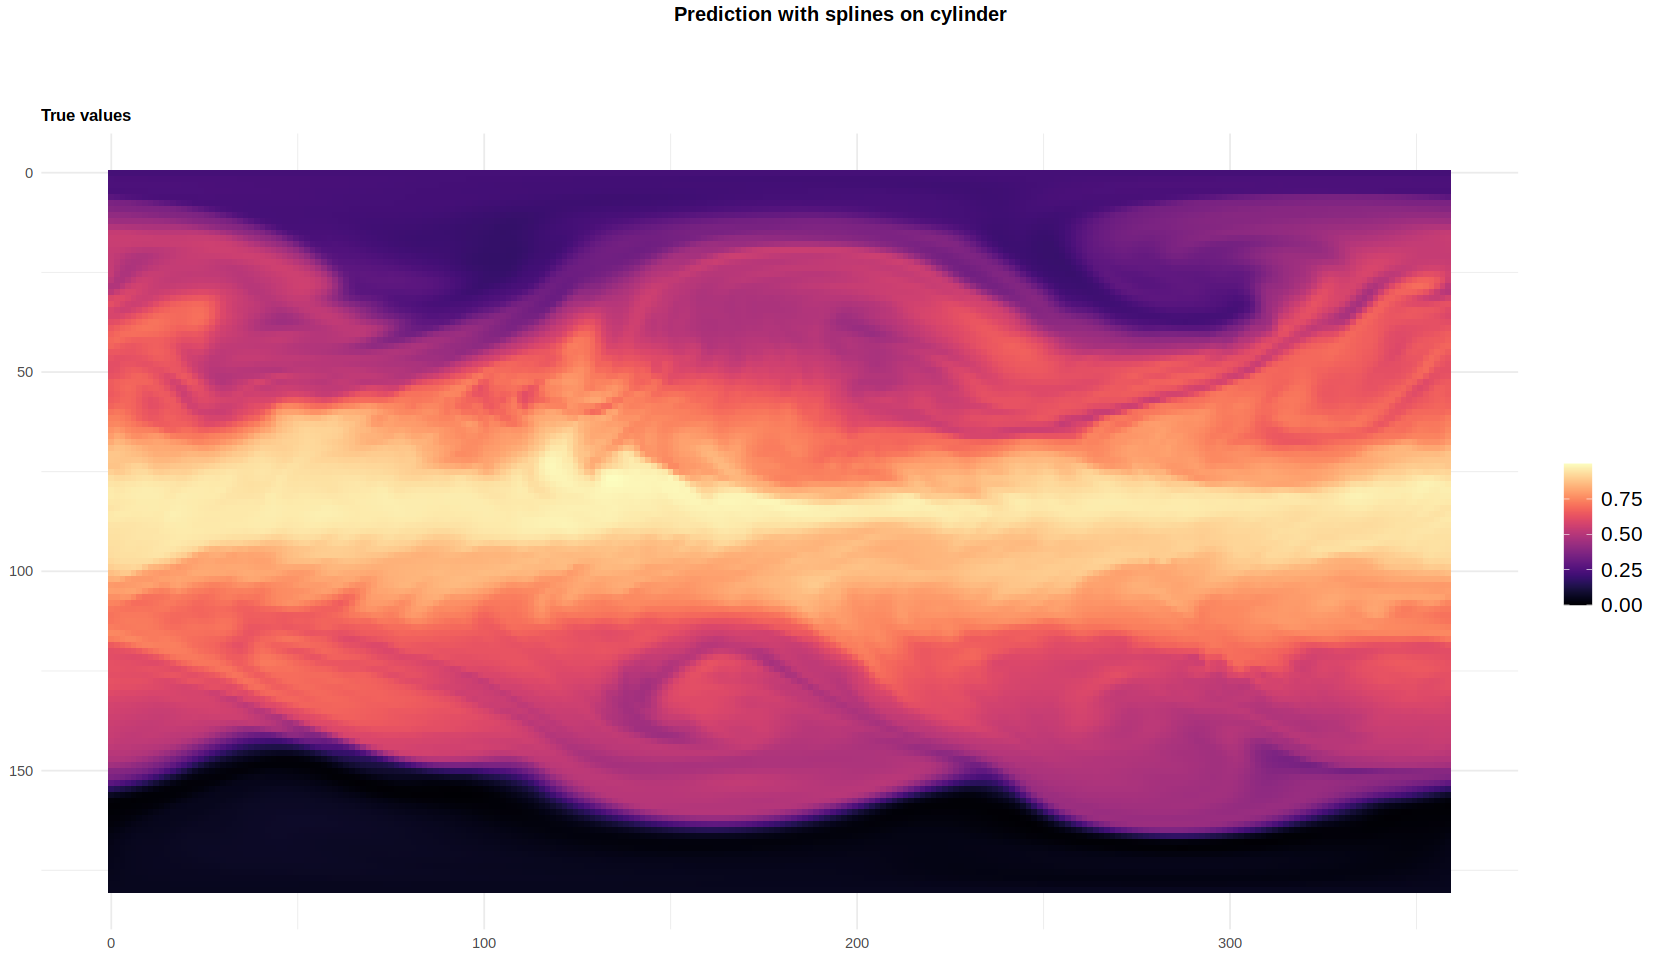

In [6]:
noise = 0 #interpolating splines here
jacob = jacob_sphere
df = read.csv("data_carbon.csv")
colnames(df) = c("theta","phi","carbon")


df$carbon = (df$carbon-min(df$carbon))/(max(df$carbon)-min(df$carbon)) #normalize data

df$theta = 90-df$theta #convert theta to [0,180]

df[df$phi < 0,]$phi = 360+df[df$phi < 0,]$phi #convert phi to [0,360]

df = df[order(df$theta, df$phi),]
kphi = sort(unique(df$phi))[seq(1, length(unique(df$phi)), by = 2)] #keep phi every 1.5°
ktheta = sort(unique(df$theta))[seq(1, length(unique(df$theta)), by = 2)] #keep theta every 1.5°
df = df[(df$phi %in% kphi) & (df$theta %in% ktheta),]
plot_multiple_columns(df, coords = c("phi","theta"), list_value = c("carbon"), name = "", list_titles = c("True values"), big_title = "Prediction with splines on cylinder", ncol=1,add_func = scale_y_reverse)


### Build triangulation

In [7]:
set.seed(13)

phi = sort(unique(df$phi))
theta = sort(unique(df$theta))[2:(length(unique(df$theta))-1)] #remove poles: theta = 0 and theta = 180
theta = c(0.1,theta, 179.9) #add points close to poles for the triangulation
list_tri = build_triangu(radius = 1,theta = theta, phi = phi) #build triangulation

communs <- merge(list_tri$points_2d, df[,c(2,1)])
node_in_df <- which(do.call(paste, list_tri$points_2d) %in% do.call(paste, communs)) #keep in mind the points of the triangulations that are points with data


### Build design of observations

In [8]:
set.seed(100)

n = 50 # number of points

design = lhsDesign(n, 2, seed=100)$design #lhs design
design = maximinESE_LHS(design)$design #maximin lhs design

design[,1] = design[,1]*180
design[,2] = design[,2]*360

dist2 = function(x1,x2){
  return(sum((x1-x2)^2))
}

idx_obs = apply(design, 1, function(x){which.min(apply(list_tri$points_2d[node_in_df,],1, function(y){dist2(x,y)}))}) #find the closest points in the triangulation (first scenario)
idx_obs = node_in_df[idx_obs] 

idx_obs = idx_obs[!duplicated(idx_obs)] #remove the potential duplicated observation points
df_obs = list_tri$points_2d[idx_obs, ] 

df_obs = merge(df_obs, df[,c("theta","phi","carbon")], by = c("theta", "phi"),sort = FALSE) #get the observation values

if(any(duplicated(df_obs[,1:2]))){stop('Error: Duplicated observations')} #check that there is no duplicated observation

if(save_data){write.csv(df_obs[,1:2], paste(save_path , "design.csv", sep=""), row.names = FALSE)}

A = A_func(list_tri = list_tri, sparse = TRUE, all_in_tri = TRUE, idx_obs  = idx_obs) #Compute the projection matrix


### Isotropic splines

In [ ]:
list_augmented = augmented_matrices(list_tri, var_a0 = NULL) #Compute matrices needed for the method: sqrt_M S^2 sqrt_M,  1/sqrt(alpha)(Mphi0), phi0, and alpha
var_a0 = list_augmented$var_a0 #return the computed alpha

write.csv(var_a0, file = paste(save_path , "alpha.csv", sep=""), write.csv)

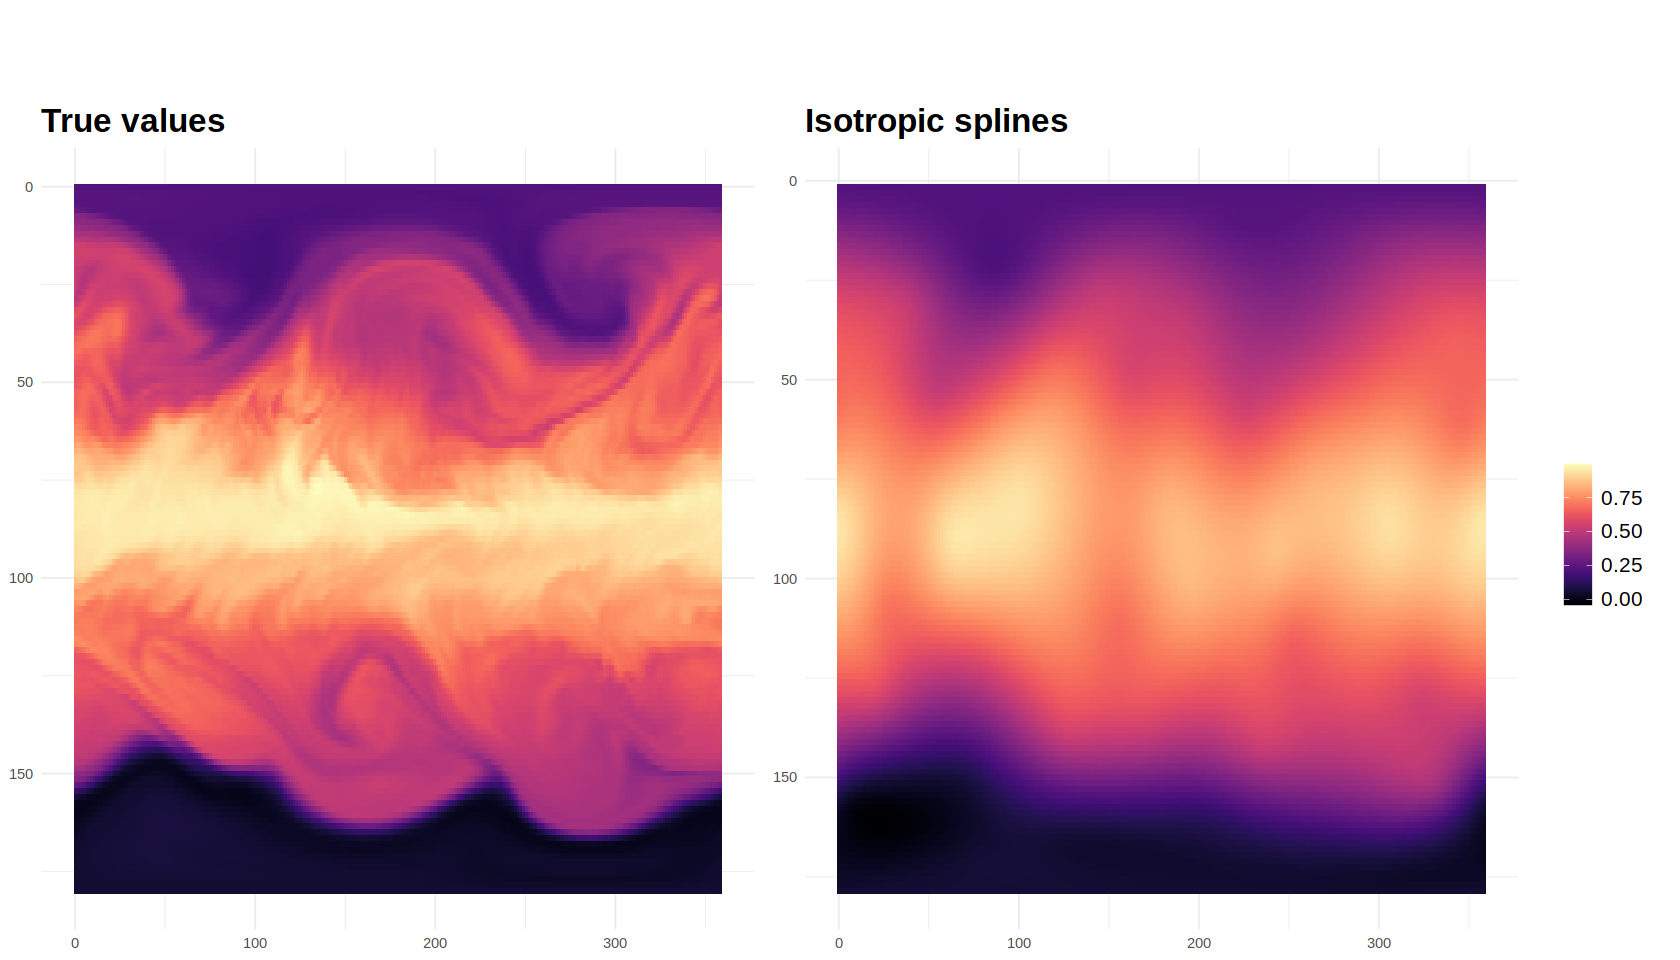

In [10]:
pred_iso = pred_func(list_tri=list_tri,y = df_obs$carbon, AA = A, idx_obs = idx_obs,list_augmented=list_augmented, noise = noise) #prediction at the triangulation points

df_pred_iso = cbind(list_tri$points_2d[node_in_df,], pred_iso[node_in_df]) # prediction matrix
colnames(df_pred_iso) = c("theta","phi","carbon")
plot_multiple_df(list(df, df_pred_iso), coords = c("phi","theta"), value = "carbon", name = "", list_titles = c("True values", "Isotropic splines"), ncol=2,add_func = scale_y_reverse)

if(save_data){write.csv(df_pred_iso, paste(save_path , "df_pred_iso.csv", sep=""), row.names = FALSE)}


### Spherical harmonics

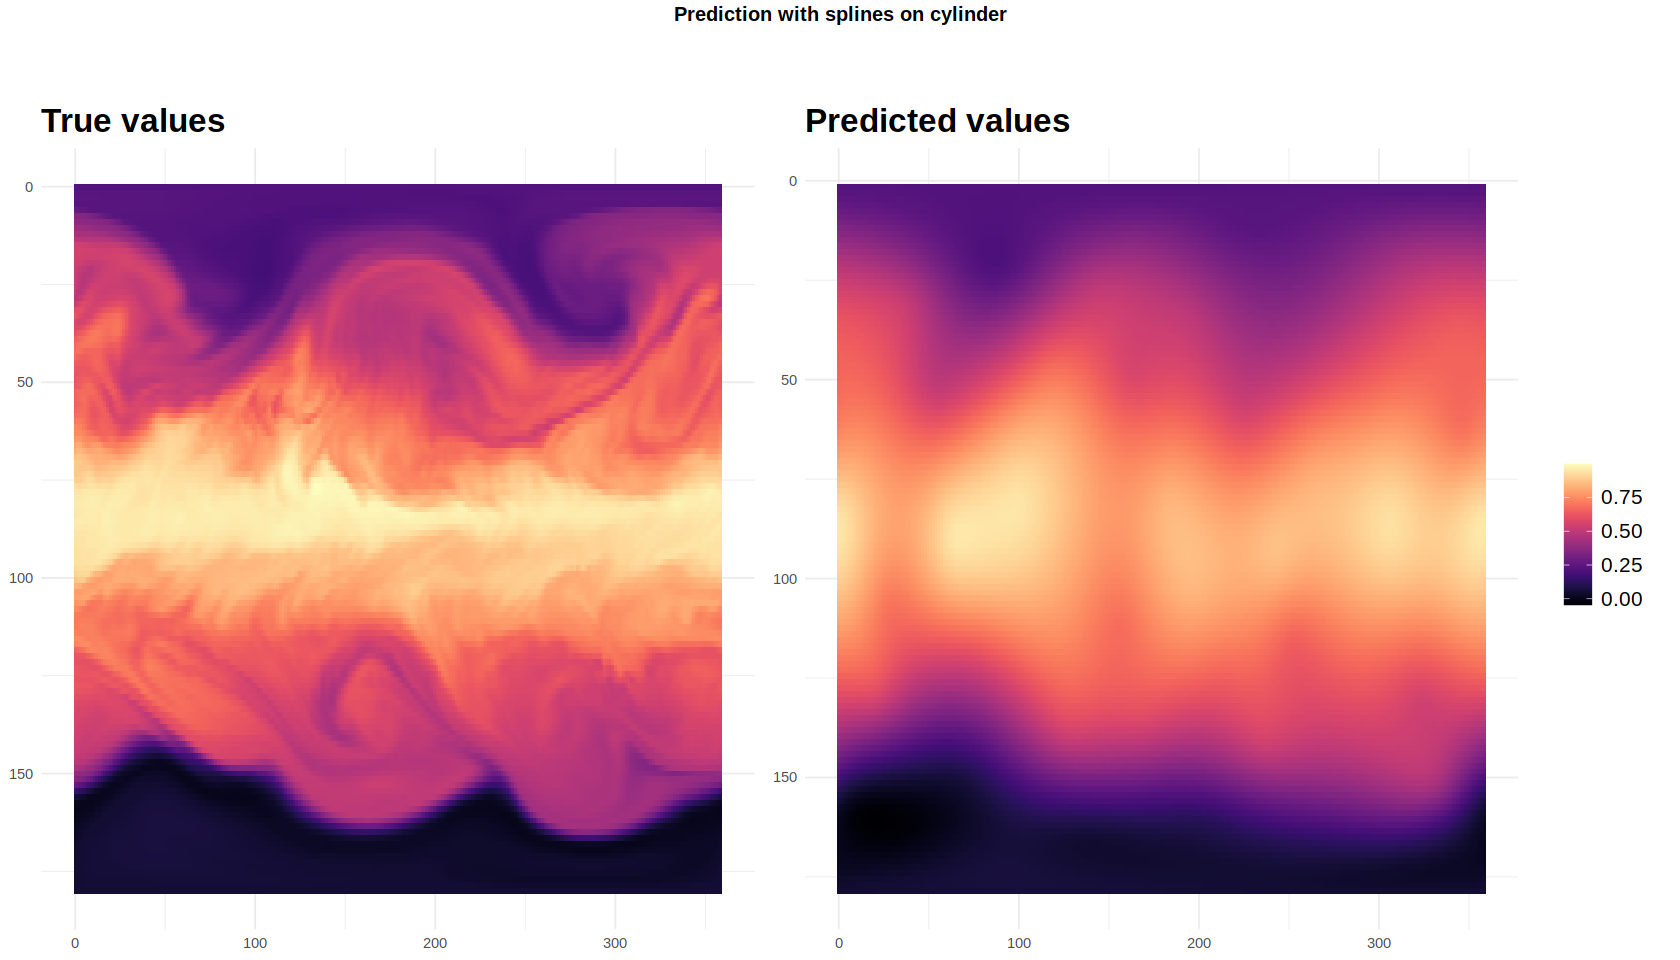

In [22]:
pred_harmo = pred_krig(df_obs = df_obs, df_pred = list_tri$points_2d,Lmax = 40, noise = noise) # prediction with spherical harmonics

df_pred_harmo = cbind(list_tri$points_2d[node_in_df,], pred_harmo[node_in_df,]) 
colnames(df_pred_harmo) = c("theta","phi","carbon")

if(save_data){write.csv(df_pred_harmo, paste(save_path , "df_pred_harmo.csv", sep=""), row.names = FALSE)}

plot_multiple_df(list(df, df_pred_harmo), coords = c("phi","theta"), value = "carbon", name = "", list_titles = c("True values", "Predicted values"), big_title = "Prediction with splines on cylinder", ncol=2, add_func =  scale_y_reverse)

 ### Pilot points for anisotropies

In [24]:
theta_pilot = c(6,36,90, 144, 174) # values of theta for the pilot points
phi_pilot = c(45,111,181.5,250.5,319.5) #values of phi for the pilot points

design_pilot = expand.grid(theta_pilot, phi_pilot) #grid of pilot points
colnames(design_pilot) = c("theta","phi")

design_pilot = design_pilot[order(design_pilot$theta),]

idx_pilot = apply(design_pilot[,1:2], 1, function(x){which.min(apply(list_tri$points_2d,1, function(y){dist2(x,y)}))}) #find closest points in the triangulation
A_pilot = A_func(list_tri = list_tri, sparse = TRUE, all_in_tri = TRUE, idx_obs  = idx_pilot) #compute the projection matrix for the triangulation


### Define function to have anisotropies on the whole sphere from the pilot points

In [25]:
list_augmented_pilot = augmented_matrices(list_tri, theta = pi/2, rho = c(5,1), var_a0 = var_a0) #Compute matrices needed for spline prediction

# The following elements are needed to compute the splines everywhere on the sphere. We compute them once and then only the values at the pilot points will change
phi_0_vec_pilot = list_augmented_pilot$phi_0_vec
Q_tilde_pilot = list_augmented_pilot$Q_tilde
idx_bar_pilot = setdiff(1:ncol(Q_tilde_pilot$Q_1), idx_pilot)
chol_Qbar_pilot = compute_chol(list(Q_1 = Q_tilde_pilot$Q_1[idx_bar_pilot, idx_bar_pilot], v = Q_tilde_pilot$v[idx_bar_pilot]))
ybis_pilot = A_pilot %*%phi_0_vec_pilot
omega_anphi0_pilot = -solve(a = chol_Qbar_pilot, b =  Q_tilde_pilot$Q_1[idx_bar_pilot, idx_pilot]%*%ybis_pilot+Q_tilde_pilot$v[idx_bar_pilot]%*%t(Q_tilde_pilot$v[idx_pilot]%*%ybis_pilot))

pred_pilot = function(y){ # spline prediction, function of the value at the pilot points
  pred_func(list_tri= list_tri, y = y,AA = A_pilot, idx_obs = idx_pilot, var_a0 = var_a0, noise = noise, list_augmented = list_augmented_pilot, chol_Qbar = chol_Qbar_pilot, omega_anphi0 = omega_anphi0_pilot)

}

### Define likelihood function 

In [28]:
fac_rho = 2 #constant scaling factor

list_tri$points_2d$.__order__ <- seq_len(nrow(list_tri$points_2d))
df_test = merge(list_tri$points_2d, df, by = c("theta","phi"), sort = FALSE, all.x = TRUE) #this dataframe associate each triangulation point to its carbon value if it exists
df_test <- df_test[order(df_test$.__order__), ]  #df_test have the same order than list_tri$points_2d
df_test$.__order__ = NULL
list_tri$points_2d$.__order__ = NULL

ll_earth = function(param, list_tri, AA, y, idx_obs, var_a0 = var_a0, noise = 0, return_anis = FALSE){ #likelihood function, the parameters are the values of the rotation angles at the pilot points
    vec_pilot = rep(0, 25)
    vec_pilot[c(1:5,11:15, 21:25)] = param[1] #to reduce the number of parameters, the same rotation angle is given to these points
    vec_pilot[setdiff(1:25,c(1:5,11:15, 21:25))] = param[2:length(param)] 
    all_angles = pred_pilot(vec_pilot) #predict the values of the rotation angles at all points, with spline interpolation
    df_test$angles = all_angles #the angles are attributed to the triangulation points
    theta = as.matrix(sapply(1:nrow(list_tri$triangles), function(tri_idx){mean(as.numeric(df_test[list_tri$triangles[tri_idx,],"angles"]))})) #for each triangle, the rotation angle is the mean of the rotations at each corner
    coeff_rho = rep(fac_rho, nrow(theta)) #the constant scaling factor for every triangle
    rho = cbind(coeff_rho, 1/coeff_rho) 
    if(return_anis){return(cbind(theta,rho))}
    res = ll_func(cbind(theta, rho), list_tri, AA, y, var_a0 = var_a0, noise = noise, idx_obs = idx_obs, constant_anisotropies = FALSE) #Compute the log-likelihood these theta and rho
    return(res)
}

In [29]:
fun=function(param){return(-ll_earth(param, list_tri = list_tri, AA = A, y = df_obs$carbon,idx_obs = idx_obs, var_a0 = var_a0, noise = 0))}

st = Sys.time()
fun(rep(pi/2, 11))
Sys.time()-st

[1] -160.0491

Time difference of 1.306518 mins

### Optimization of the anistropy parameters

In [35]:
if(optim){
    lambd = 5 # lambda in cmaes
    budget = 500 #budget for optimization: number of likelihood computations
    path = paste(save_path , "eval_cma.csv", sep="") 
    d_param = 11 #number of parameters
    
    fun=function(param){return(-ll_earth(param, list_tri = list_tri, AA = A, y = df_obs$carbon,idx_obs = idx_obs, var_a0 = var_a0, noise = noise))}  #likelihood function
    
    f_vec <- function(X, save = TRUE) { #vectorize the likelihood function for parallel optimization, and save the results
        df_follow = as.matrix(read.csv(path))
        res = as.numeric(mclapply(1:ncol(X), function(i) fun(X[,i]), mc.cores = lambd))
        if(save){write.csv(rbind(df_follow,cbind(t(X), res)), path, row.names = FALSE)}
      return(res)
    }
    
    write.csv( data.frame(t(rep(0, d_param+1))), path, row.names = FALSE) #this csv file will contains all likelihood evaluations
    set.seed(100)
    opt_cma=cma_es(par = c(rep(pi/2,d_param)), fn = f_vec, lower= c(rep(0, d_param)), upper =c(rep(pi-0.01,d_param)), control = list(lambda = lambd,maxit = budget%/%lambd, keep.best = TRUE, diag.pop=TRUE, diag.value = TRUE, sigma = 0.15, diag.sigma = TRUE, vectorized=TRUE)) # optimization with cmaes
    df_follow = as.matrix(read.csv(path))[-1,]
    psi_opt = as.numeric(df_follow[which.min(df_follow[,ncol(df_follow)]),-ncol(df_follow)]) #get best parameters
    write.csv( data.frame(t(psi_opt)),  paste(save_path , "psi_opt.csv", sep="") , row.names = FALSE) #save best parameters
}


### Prediction with anisotropic finite-element splines

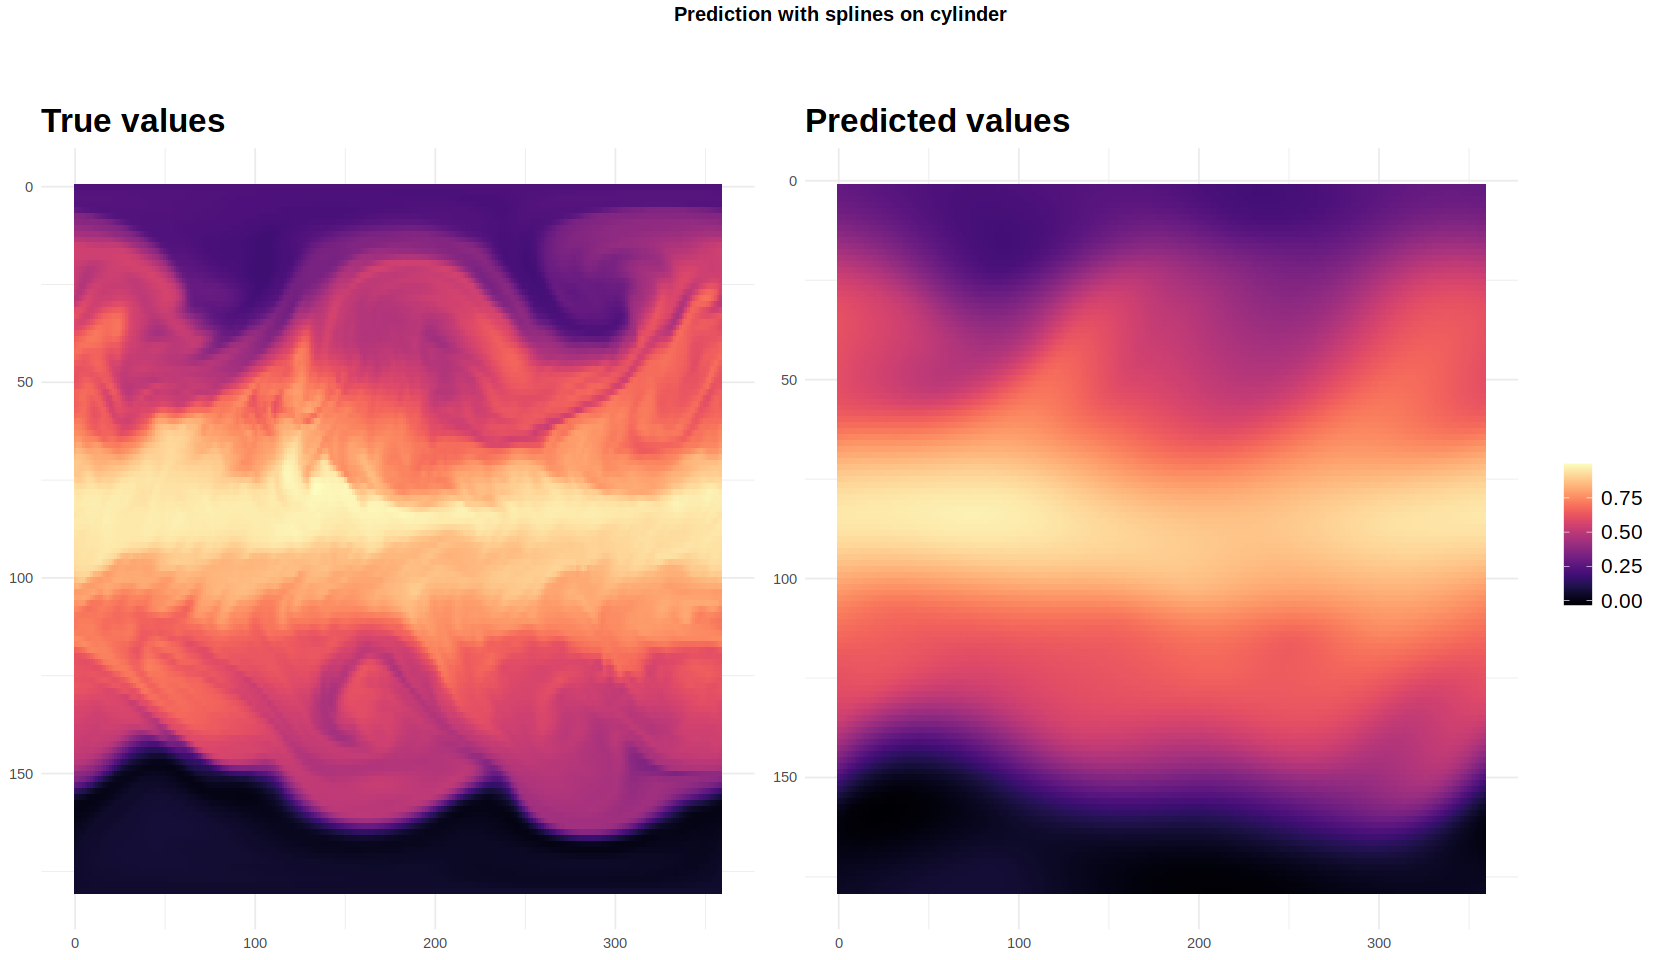

In [40]:
psi_opt = as.numeric(read.csv(  paste(save_path , "psi_opt.csv", sep=""))) #get best parameters
param_anis = ll_earth(psi_opt, list_tri = list_tri, AA = A, y = df_obs$carbon,idx_obs = idx_obs, var_a0 = var_a0, noise = 0, return_anis = TRUE) #get theta and rho
pred_aniso = pred_func(list_tri = list_tri, y = df_obs$carbon, AA = A, idx_obs = idx_obs, var_a0 = var_a0, theta = matrix(param_anis[,1]), rho = param_anis[,2:3] ) #anisotropic prediction
df_pred_aniso = cbind(list_tri$points_2d[node_in_df,], pred_aniso[node_in_df]) # prediction matrix
colnames(df_pred_aniso) = c("theta","phi","carbon")

if(save_data){write.csv(df_pred_aniso, paste(save_path , "df_pred_aniso.csv", sep=""), row.names = FALSE)}

plot_multiple_df(list(df, df_pred_aniso), coords = c("phi","theta"), value = "carbon", name = "", list_titles = c("True values", "Predicted values"), big_title = "Prediction with splines on cylinder", ncol=2, add_func =  scale_y_reverse)

In [56]:
df_true = df_test[!(df_test$theta %in% c(0.1,179.9)),]
write.csv(df_true, file =  paste(save_path , "df_test.csv", sep=""), row.names = FALSE)